This page aims to reproduce the Numerical Experiment from Section 4 of Margossian et al. Some of the plotting code is from analyze_results.ipynb    

In [ ]:
!pip install -Uq tfp-nightly[jax]
!pip install inference_gym
!pip install tf-nightly

# remember to restart runtime after changing the environment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.3/630.3 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 33.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 require

In [ ]:
import numpy as np
from copy import deepcopy
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

# from matplotlib.pyplot import *

import os
# in case jax eats up my GPU RAM
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax
from jax import random
from jax import numpy as jnp

# from inference_gym import using_jax as gym

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions
from inference_gym import using_jax as gym
tfb = tfp.bijectors

from tensorflow_probability.substrates import numpy as tfp_np
tfd_np = tfp_np.distributions

import matplotlib.pyplot as plt

import pandas as pd

import gc

# check if this is run on a gpu
print(jax.devices())
print(jax.default_backend())

import warnings
warnings.filterwarnings('ignore')

import psutil

process = psutil.Process(os.getpid())

def mem(msg):
    print(f"{msg}: {process.memory_info().rss / 1024**2:.1f} MB")

[CudaDevice(id=0)]
gpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
utility_link = '/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/utility.py'
with open(utility_link) as f: exec(f.read())

The code block below is tying to replicate section 4.2 of the nest R hat paper, quote:  
" In this case, we may run 2048 chains, broken into
K =16 superchains and M = 128 subchains. For each target distribution, we compute
Rν using N = 1 draw after warmups of varying lengths,
W=(10,20,30,...,100,200,300,...,1000)."  
we will repeat this experiment 10 times for each distribution.



**Initial Setups**

In [ ]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

In [ ]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
num_chains_short = 2048
num_super_chains = 16
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

**Rosenbrock Example**

In [ ]:
target = gym.targets.VectorModel(gym.targets.Banana(),
                                 flatten_sample_transformations=True)
num_dimensions = target.event_shape[0]
init_step_size = 1.

def target_log_prob_fn(x):
  """Unnormalized, unconstrained target density.

  This is a thin wrapper that applies the default bijectors so that we can
  ignore any constraints.
  """
  y = target.default_event_space_bijector(x)
  fldj = target.default_event_space_bijector.forward_log_det_jacobian(x)
  return target.unnormalized_log_prob(y) + fldj

# NOTE: Avoid initials centered around the true mean.
offset = 2
def initialize (shape, key):
  return 10 * random.normal(key, shape + (num_dimensions,)) + offset

In [ ]:
# Get some estimates of the mean and variance.
try:
  mean_est = target.sample_transformations['identity'].ground_truth_mean
except:
  print('no ground truth mean')
  mean_est = (result.all_states[num_warmup:, :]).mean(0).mean(0)
try:
  var_est = target.sample_transformations['identity'].ground_truth_standard_deviation**2
except:
  print('no ground truth std dev')
  var_est = ((result.all_states[num_warmup:, :]**2).mean(0).mean(0) -
             mean_est**2)
mean_benchmark = mean_est
var_benchmark = var_est

[0. 0.]


In [ ]:
#simulation part:
MSE_constrained_list = []
MSE_naive_list = []
R_Hat_constrained_list = []
R_Hat_naive_list = []
state_list_constrained = []
state_list_naive = []

Roughly 23 mins for simulation to be done.

In [ ]:
base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)

for length in warmup_length:
  mem(f"Simulation start")
  simulation(
            keys,initialize,
            length,1,
            False, repitition,True,
            MSE_constrained_list,R_Hat_constrained_list,
            num_dimensions, state_list_constrained,
            mean_benchmark,var_benchmark,
            num_super_chains,num_chains_short,
            target_log_prob_fn, init_step_size)
  simulation(
            keys,initialize,
            length,1,
            True, repitition,True,
            MSE_naive_list,R_Hat_naive_list,
            num_dimensions, state_list_naive,
            mean_benchmark,var_benchmark,
            num_super_chains,num_chains_short,
            target_log_prob_fn, init_step_size)

Simulation start: 1517.1 MB
Constrained initialization. Warmup Length: 10; mean of MSE is: 0.05848374217748642
Naive initialization. Warmup Length: 10; mean of MSE is: 0.016667047515511513
Simulation start: 1853.8 MB
Constrained initialization. Warmup Length: 20; mean of MSE is: 0.05551811307668686
Naive initialization. Warmup Length: 20; mean of MSE is: 0.015999462455511093
Simulation start: 1857.1 MB
Constrained initialization. Warmup Length: 30; mean of MSE is: 0.05175480246543884
Naive initialization. Warmup Length: 30; mean of MSE is: 0.014839982613921165
Simulation start: 1868.0 MB
Constrained initialization. Warmup Length: 40; mean of MSE is: 0.047594379633665085
Naive initialization. Warmup Length: 40; mean of MSE is: 0.014106961898505688
Simulation start: 1882.1 MB
Constrained initialization. Warmup Length: 50; mean of MSE is: 0.04386571794748306
Naive initialization. Warmup Length: 50; mean of MSE is: 0.01348606776446104
Simulation start: 1899.3 MB
Constrained initialization.

In [ ]:
MSE_c_df = pd.DataFrame(MSE_constrained_list)
R_Hat_c_df = pd.DataFrame(R_Hat_constrained_list)
state_c_df = pd.DataFrame(state_list_constrained)
MSE_n_df = pd.DataFrame(MSE_naive_list)
R_Hat_n_df = pd.DataFrame(R_Hat_naive_list)
state_n_df = pd.DataFrame(state_list_naive)

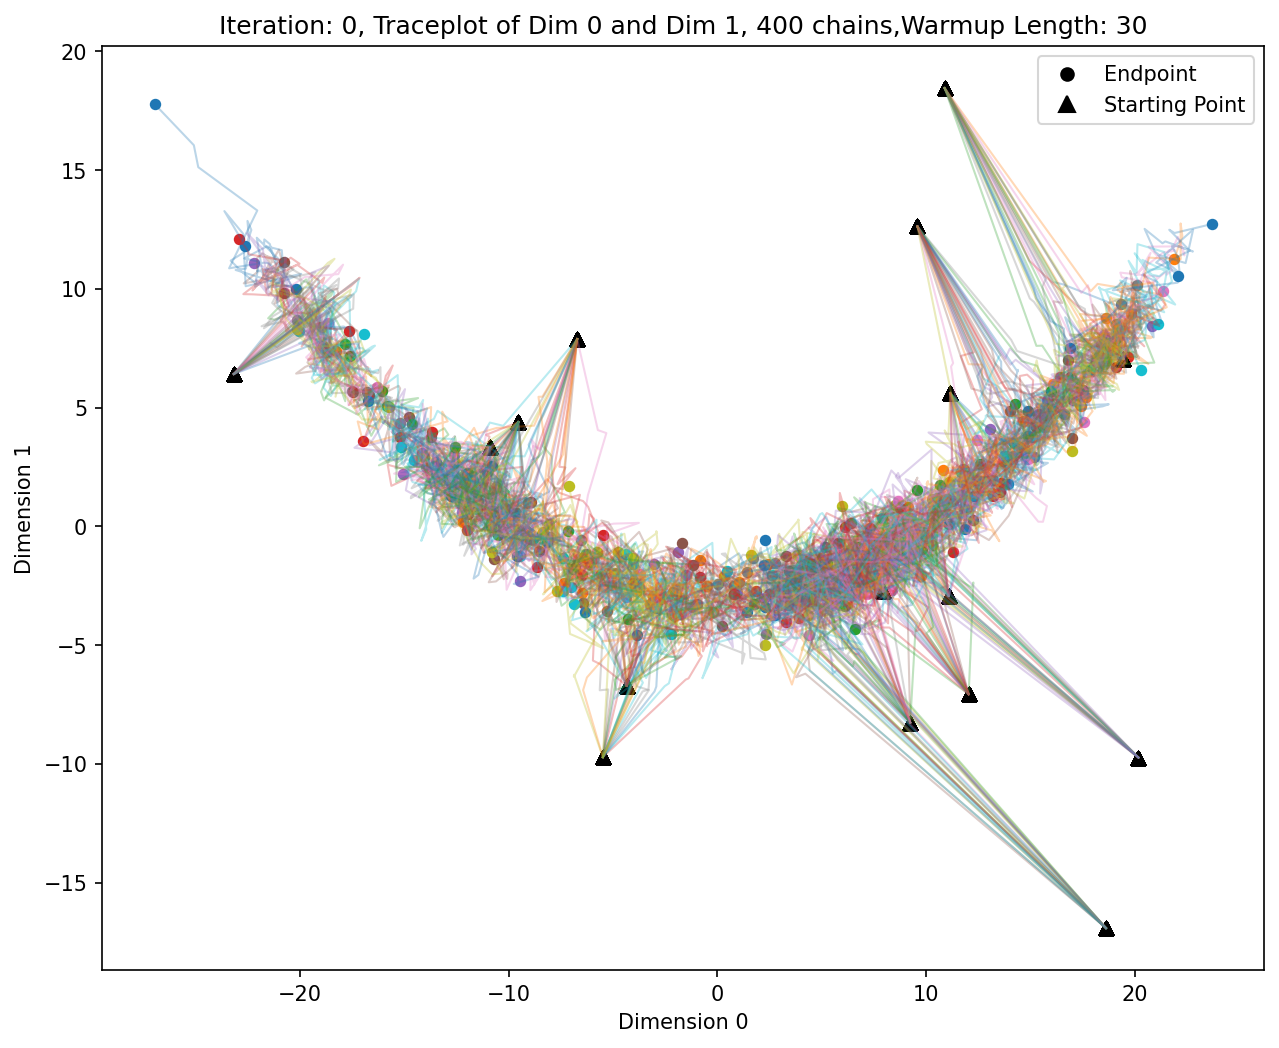

In [ ]:
trace_plot(state_c_df,0,30,0,1,400,False)

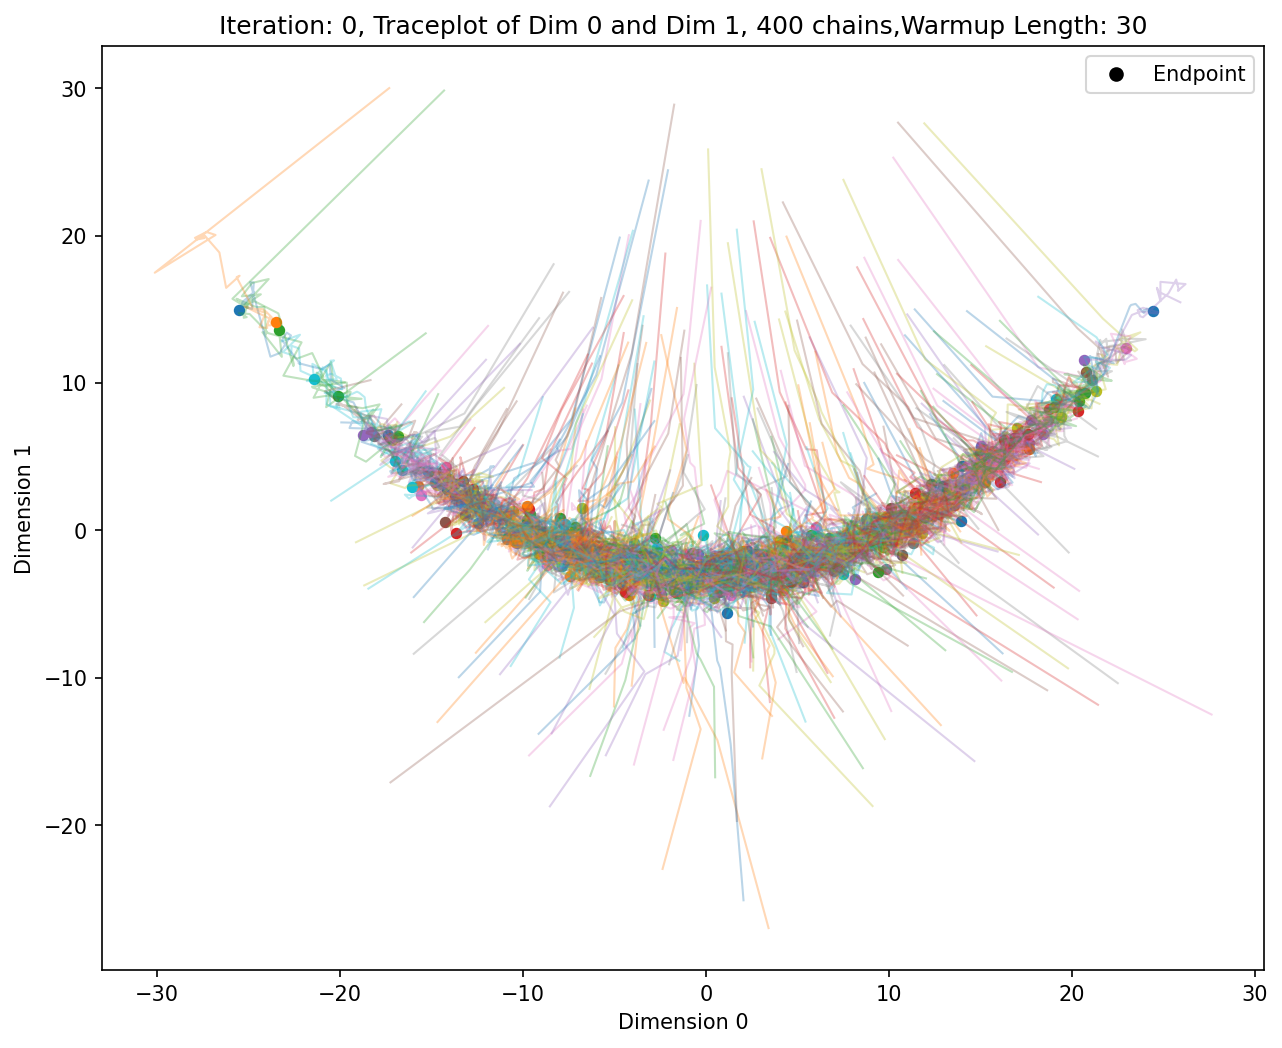

In [ ]:
trace_plot(state_n_df,0,30,0,1,400,True)

Save result to file

In [ ]:
MSE_c_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_MSE_constrained.pkl"
)

MSE_n_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_MSE_naive.pkl"
)

R_Hat_c_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_R_Hat_constrained.pkl"
)

R_Hat_n_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_R_Hat_naive.pkl"
)

**Bimodal Example**

In [ ]:
num_dimensions = 100
dist = tfd.MixtureSameFamily(
    mixture_distribution=tfd.Categorical(probs=[0.3, 0.7]),
    components_distribution=tfd.MultivariateNormalDiag(
      loc=[jnp.repeat(-5., num_dimensions), jnp.repeat(5., num_dimensions)],
      scale_diag=jnp.repeat(1., num_dimensions)))

def target_log_prob_fn(x):
  return dist.log_prob(x)

offset = 0
def initialize (shape, key):
  return 10 * random.normal(key, shape + (num_dimensions,)) + offset

mean_est = jnp.repeat(2, num_dimensions)
var_est = jnp.repeat(22, num_dimensions)

init_step_size = 1

mean_benchmark = mean_est
var_benchmark = var_est

In [ ]:
base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)

Bimodal_MSE_constrained_list = []
Bimodal_MSE_naive_list = []
Bimodal_R_Hat_constrained_list = []
Bimodal_R_Hat_naive_list = []
Bimodal_state_list_constrained = []
Bimodal_state_list_naive = []

In [ ]:
#simulation part:
for length in warmup_length:
  mem(f"Simulation start")
  simulation(
            keys,initialize,
            length,1,
            False,repitition,True,
            Bimodal_MSE_constrained_list,
            Bimodal_R_Hat_constrained_list,
            num_dimensions,Bimodal_state_list_constrained,
            mean_benchmark,var_benchmark,
            num_super_chains,num_chains_short,
            target_log_prob_fn, init_step_size
            )
  simulation(
            keys,initialize,
            length,1,
            True,repitition,True,
            Bimodal_MSE_naive_list,
            Bimodal_R_Hat_naive_list,
            num_dimensions,Bimodal_state_list_naive,
            mean_benchmark,var_benchmark,
            num_super_chains,num_chains_short,
            target_log_prob_fn, init_step_size
            )

Simulation start: 1412.6 MB
Constrained initialization. Warmup Length: 10; mean of MSE is: 0.285150945186615
Naive initialization. Warmup Length: 10; mean of MSE is: 0.18057803809642792
Simulation start: 2102.1 MB
Constrained initialization. Warmup Length: 20; mean of MSE is: 0.2861376404762268
Naive initialization. Warmup Length: 20; mean of MSE is: 0.18018120527267456
Simulation start: 2471.2 MB
Constrained initialization. Warmup Length: 30; mean of MSE is: 0.2864880859851837
Naive initialization. Warmup Length: 30; mean of MSE is: 0.18030524253845215
Simulation start: 2996.7 MB
Constrained initialization. Warmup Length: 40; mean of MSE is: 0.2866274118423462
Naive initialization. Warmup Length: 40; mean of MSE is: 0.180461585521698
Simulation start: 3682.5 MB
Constrained initialization. Warmup Length: 50; mean of MSE is: 0.2867785692214966
Naive initialization. Warmup Length: 50; mean of MSE is: 0.18050223588943481
Simulation start: 4520.3 MB
Constrained initialization. Warmup Lengt

In [ ]:
Bimodal_MSE_c_df = pd.DataFrame(Bimodal_MSE_constrained_list)
Bimodal_R_Hat_c_df = pd.DataFrame(Bimodal_R_Hat_constrained_list)
Bimodal_state_c_df = pd.DataFrame(Bimodal_state_list_constrained)
Bimodal_MSE_n_df = pd.DataFrame(Bimodal_MSE_naive_list)
Bimodal_R_Hat_n_df = pd.DataFrame(Bimodal_R_Hat_naive_list)
Bimodal_state_n_df = pd.DataFrame(Bimodal_state_list_naive)

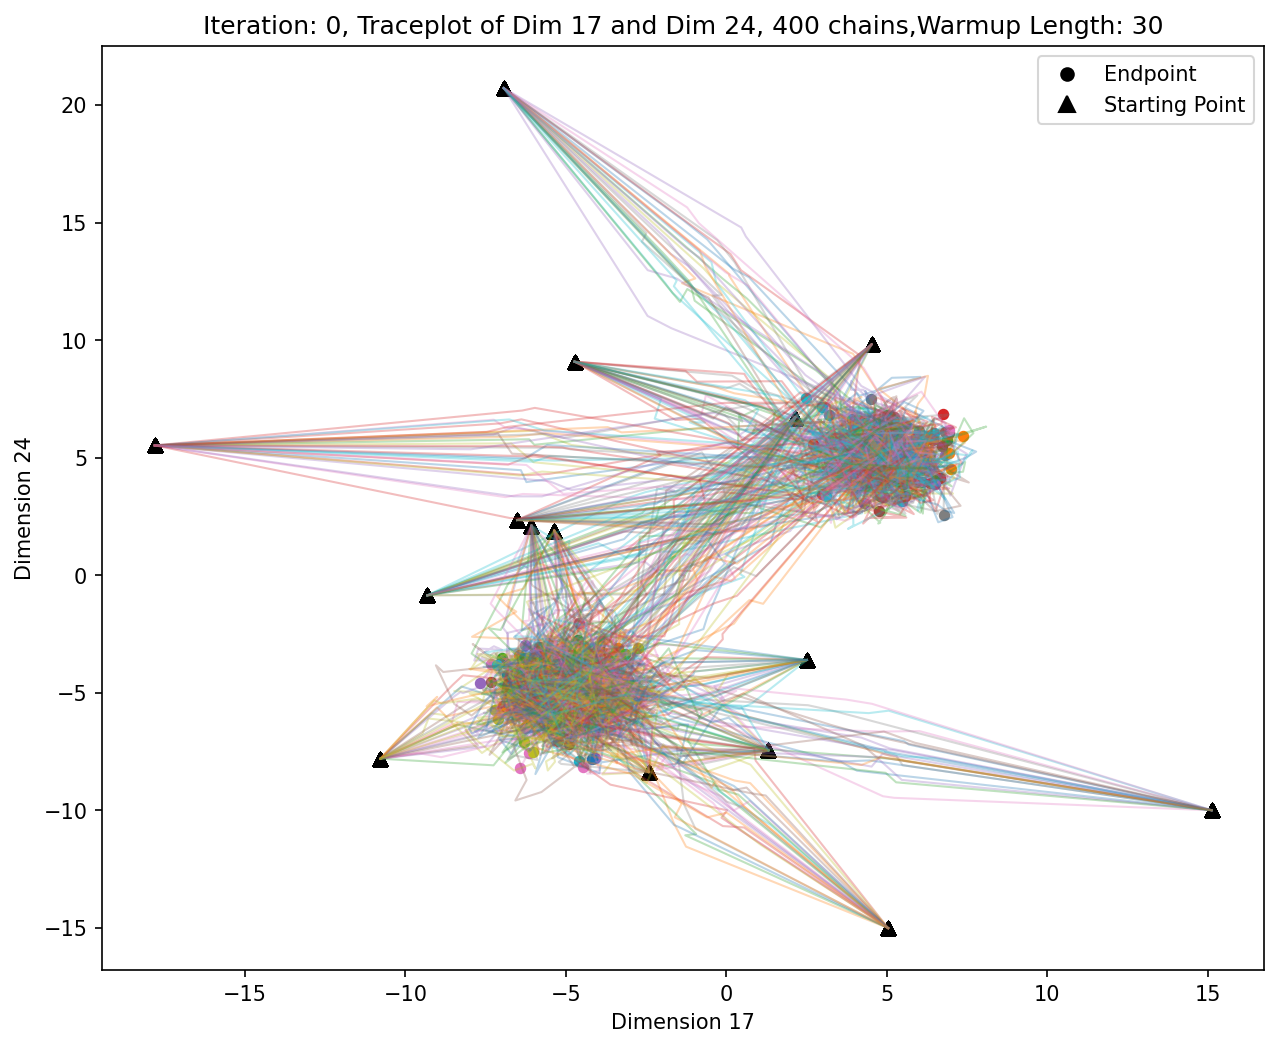

In [ ]:
trace_plot(Bimodal_state_c_df,0,30,17,24,400,False)

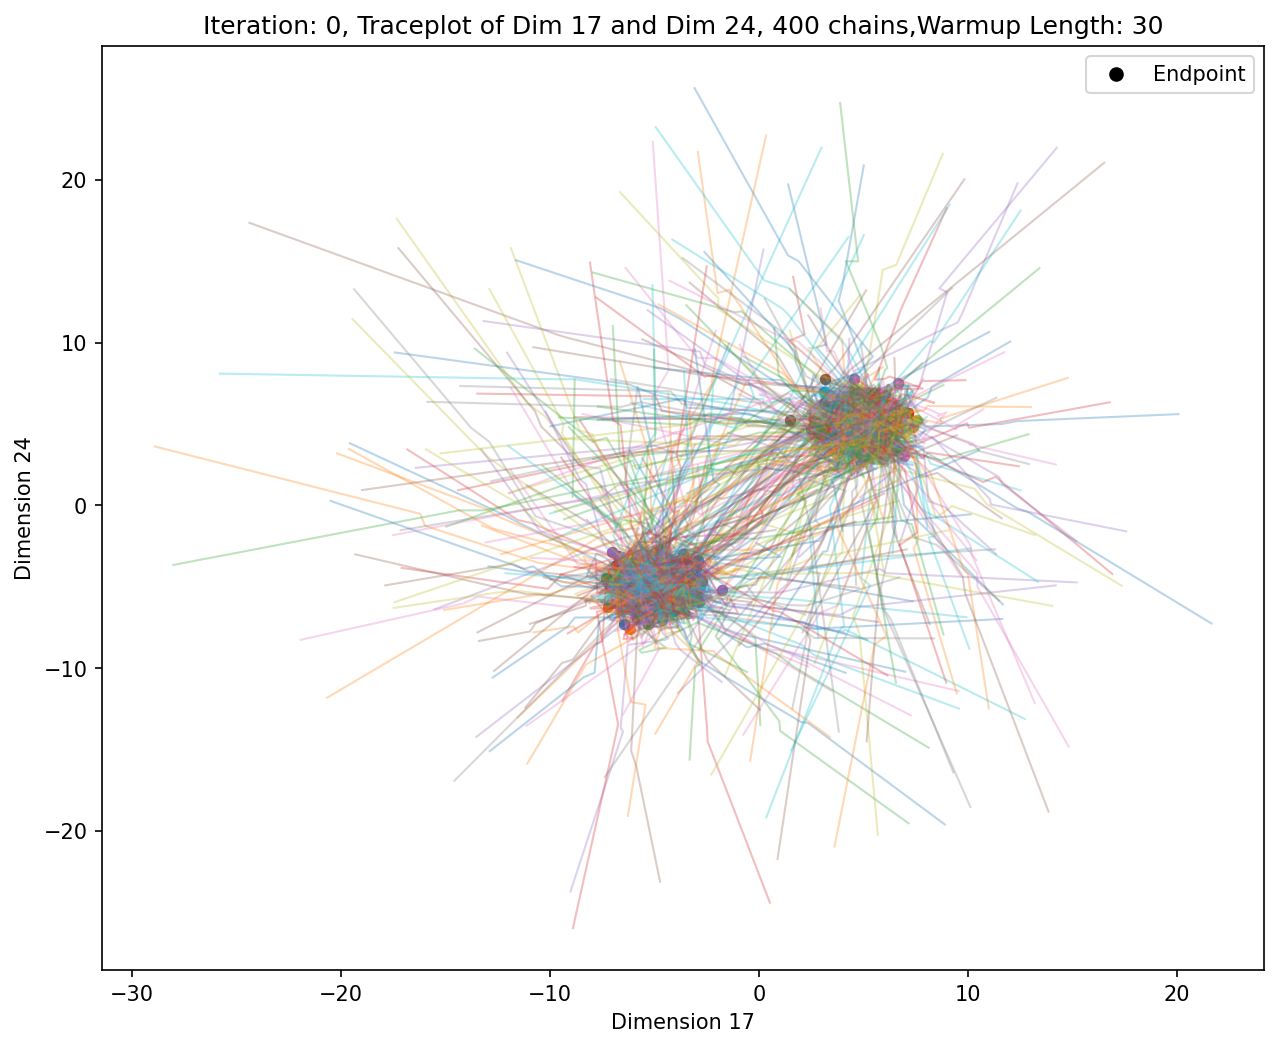

In [ ]:
trace_plot(Bimodal_state_n_df,0,30,17,24,400,True)

In [ ]:
Bimodal_MSE_c_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_MSE_constrained.pkl"
)

Bimodal_MSE_n_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_MSE_naive.pkl"
)

Bimodal_R_Hat_c_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_R_Hat_constrained.pkl"
)

Bimodal_R_Hat_n_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_R_Hat_naive.pkl"
)

Perhaps we can try other distributions...?  
German Credit Score and PK requires some other package.  

Let's try the eight school thing

**Eight School Example**

In [ ]:
# NOTE: inference gym stores the centered parameterization
target_raw = gym.targets.EightSchools()  # store raw to examine doc.
target = gym.targets.VectorModel(target_raw,
                                  flatten_sample_transformations = True)
num_dimensions = target.event_shape[0]
init_step_size = 1

# Using underdispersed initis can show case problems with our diagnostics.
# underdispered = False
# Options: underdispersed, overdispersed, prior
init_type = "prior"
if init_type == "underdispersed":
  offset = 0.0
  def initialize (shape, key = random.PRNGKey(37272709)):
    return 1 * random.normal(key, shape + (num_dimensions,)) + offset
elif init_type == "overdispersed":
  offset = 0.0
  def initialize (shape, key = random.PRNGKey(37272709)):
    return 100 * random.normal(key, shape + (num_dimensions,)) + offset
elif init_type == "prior":
  def initialize (shape, key = random.PRNGKey(37272709)):
    prior_scale = jnp.append(jnp.array([10., 1.]), jnp.repeat(1., 8))
    prior_offset = jnp.append(jnp.array([0., 5.]), jnp.repeat(0., 8))
    return prior_scale * random.normal(key, shape + (num_dimensions,)) + prior_offset

In [ ]:
num_schools = 8
y = np.array([28, 8, -3, 7, -1, 1, 18, 12], dtype = np.float32)
sigma = np.array([15, 10, 16, 11, 9, 11, 10, 18], dtype = np.float32)

# NOTE: the reinterpreted batch dimension specifies the dimension of
# each indepdent variable, here the school.
model = tfd.JointDistributionSequential([
    tfd.Normal(loc = 0., scale = 10., name = "mu"),
    tfd.Normal(loc = 5., scale = 1., name = "log_tau"),
    tfd.Independent(tfd.Normal(loc = jnp.zeros(num_schools),
                               scale = jnp.ones(num_schools),
                               name = "eta"),
                    reinterpreted_batch_ndims = 1),
    lambda eta, log_tau, mu: (
        tfd.Independent(tfd.Normal(loc = (mu[..., jnp.newaxis] +
                                        jnp.exp(log_tau[..., jnp.newaxis]) *
                                        eta),
                                   scale = sigma),
                        name = "y",
                        reinterpreted_batch_ndims = 1))
  ])

def target_log_prob_fn(x):
  mu = x[:, 0]
  log_tau = x[:, 1]
  eta = x[:, 2:10]
  return model.log_prob((mu, log_tau, eta, y))

In [ ]:
# Use results from running 128 chains with 1000 + 5000 iterations each,
# for non-centered parameterization.
mean_est = np.array([5.8006573 ,  2.4502006 ,  0.6532423 ,  0.09639207,
             -0.23725411,  0.04723661, -0.33556408, -0.19666635,
              0.5390533 ,  0.14633301])

var_est = np.array([29.60382   ,  0.26338503,  0.6383733 ,  0.4928926 ,
              0.65307987,  0.52441144,  0.46658015,  0.5248887 ,
              0.49544162,  0.690975])
mean_benchmark = mean_est
var_benchmark = var_est

In [ ]:
#simulation part:

base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)

School_MSE_constrained_list = []
School_MSE_naive_list = []
School_R_Hat_constrained_list = []
School_R_Hat_naive_list = []
School_state_list_constrained = []
School_state_list_naive = []


In [ ]:
#simulation part:
for length in warmup_length:
  mem(f"Simulation start")
  simulation(
            keys,initialize,
            length,1,
            False,repitition,True,
            School_MSE_constrained_list,
            School_R_Hat_constrained_list,
            num_dimensions,School_state_list_constrained,
            mean_benchmark,var_benchmark,
            num_super_chains,num_chains_short,
            target_log_prob_fn, init_step_size
            )
  simulation(
            keys,initialize,
            length,1,
            True,repitition,True,
            School_MSE_naive_list,
            School_R_Hat_naive_list,
            num_dimensions,School_state_list_naive,
            mean_benchmark,var_benchmark,
            num_super_chains,num_chains_short,
            target_log_prob_fn, init_step_size
            )

Simulation start: 1505.3 MB
Constrained initialization. Warmup Length: 10; mean of MSE is: 11.914587020874023
Naive initialization. Warmup Length: 10; mean of MSE is: 71.69624328613281
Simulation start: 1877.7 MB
Constrained initialization. Warmup Length: 20; mean of MSE is: 0.23814532160758972
Naive initialization. Warmup Length: 20; mean of MSE is: 55.280487060546875
Simulation start: 1903.4 MB
Constrained initialization. Warmup Length: 30; mean of MSE is: 0.21712712943553925
Naive initialization. Warmup Length: 30; mean of MSE is: 39.96074295043945
Simulation start: 1953.8 MB
Constrained initialization. Warmup Length: 40; mean of MSE is: 0.20221355557441711
Naive initialization. Warmup Length: 40; mean of MSE is: 29.9703426361084
Simulation start: 2026.2 MB
Constrained initialization. Warmup Length: 50; mean of MSE is: 0.18274067342281342
Naive initialization. Warmup Length: 50; mean of MSE is: 23.12778663635254
Simulation start: 2108.4 MB
Constrained initialization. Warmup Length: 

In [ ]:
School_MSE_c_df = pd.DataFrame(School_MSE_constrained_list)
School_R_Hat_c_df = pd.DataFrame(School_R_Hat_constrained_list)
School_state_c_df = pd.DataFrame(School_state_list_constrained)
School_MSE_n_df = pd.DataFrame(School_MSE_naive_list)
School_R_Hat_n_df = pd.DataFrame(School_R_Hat_naive_list)
School_state_n_df = pd.DataFrame(School_state_list_naive)

In [ ]:
School_MSE_c_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_MSE_constrained.pkl"
)

School_MSE_n_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_MSE_naive.pkl"
)

School_R_Hat_c_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_R_Hat_constrained.pkl"
)

School_R_Hat_n_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_R_Hat_naive.pkl"
)

**Trace Section**

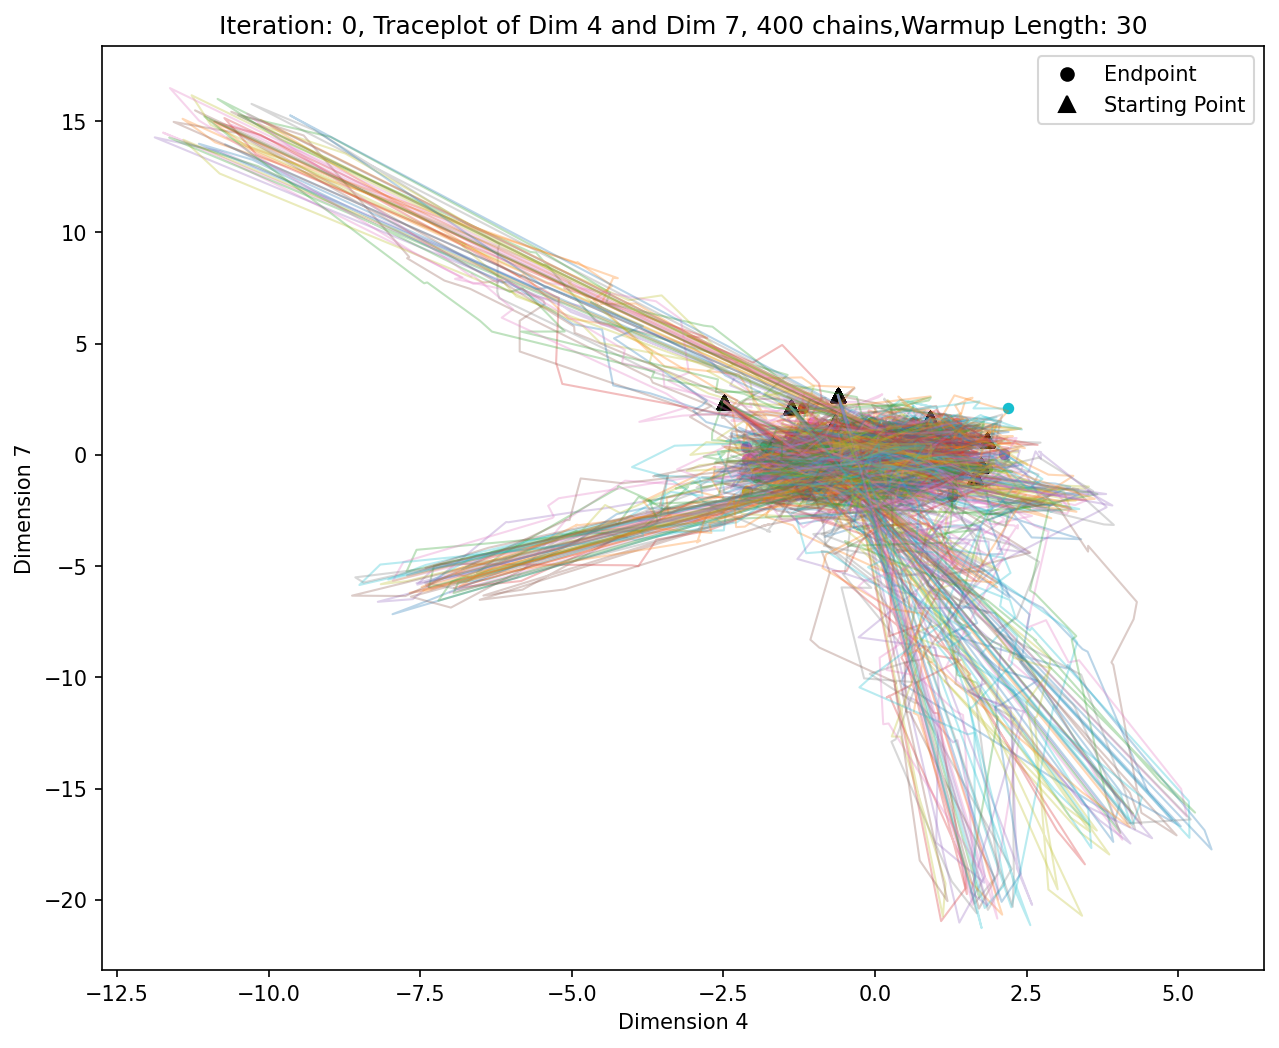

In [ ]:
trace_plot(School_state_c_df,0,30,4,7,400,False)

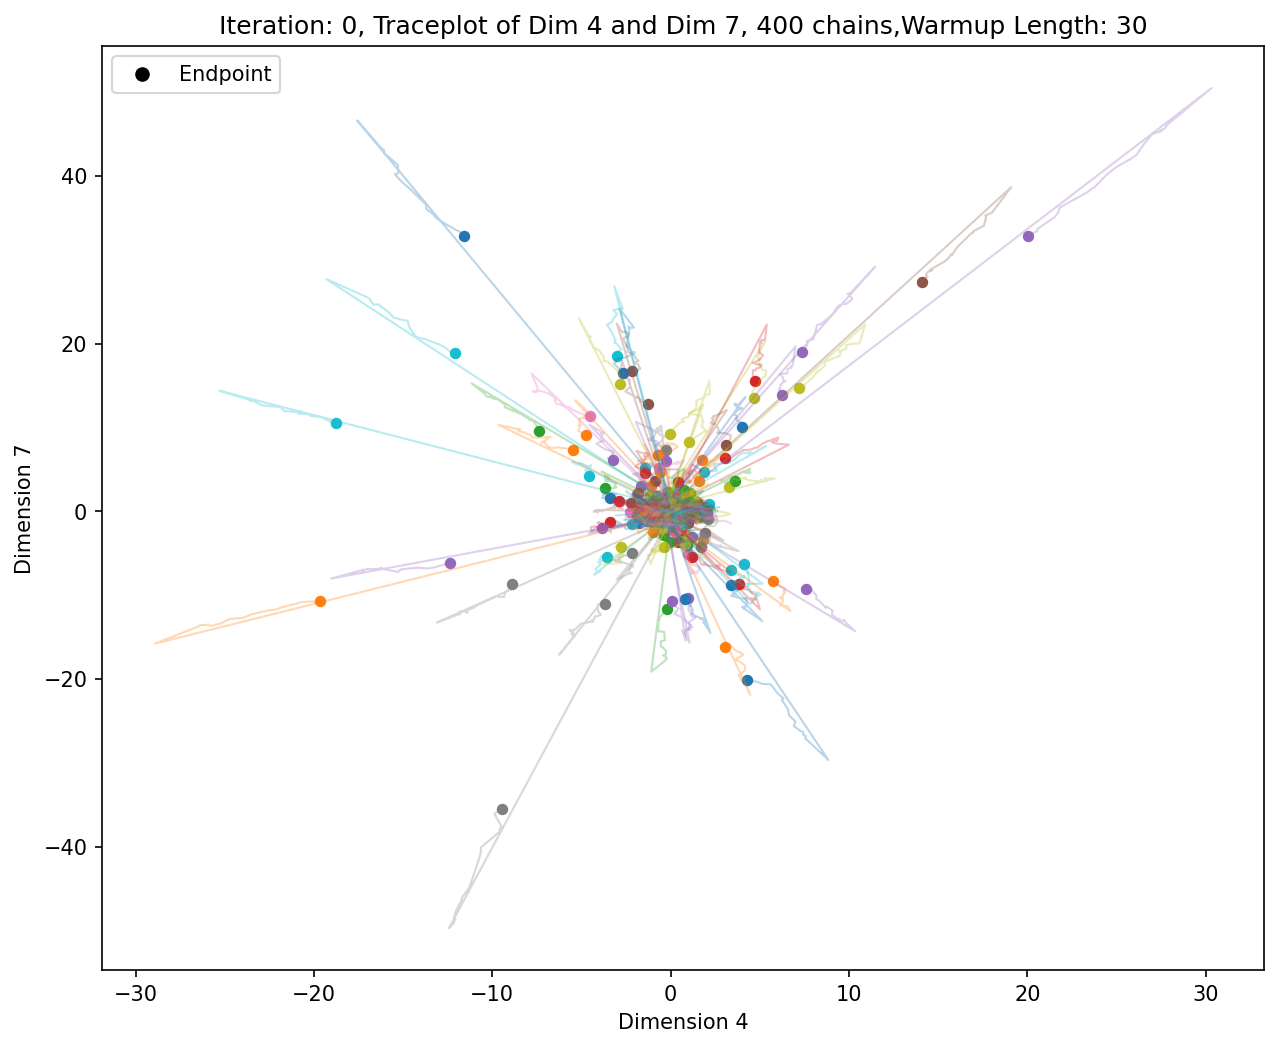

In [ ]:
trace_plot(School_state_n_df,0,30,4,7,400,True)

**Item Response Theory Example**

I would recommend using A100 for this simulation. From personal experience, using default T4 would spend more than 1 hour just go through from W=10 to W=50. Additionaly, it will take up about 16.5 GB of GPU RAM when warmup length gets higher, so T4 might not be able to handle it since it only gets 12GB of RAM  
Even with A100, running the whole thing requires about 2 hours, it will definitely take longer if it was a T4.

In [ ]:
target = gym.targets.VectorModel(gym.targets.SyntheticItemResponseTheory(),
                                 flatten_sample_transformations=True)
num_dimensions = target.event_shape[0]
init_step_size = 1.

def target_log_prob_fn(x):
  """Unnormalized, unconstrained target density.

  This is a thin wrapper that applies the default bijectors so that we can
  ignore any constraints.
  """
  y = target.default_event_space_bijector(x)
  fldj = target.default_event_space_bijector.forward_log_det_jacobian(x)
  return target.unnormalized_log_prob(y) + fldj

offset = 0
def initialize (shape, key = random.PRNGKey(37272709)):
  return 10 * random.normal(key, shape + (num_dimensions,)) + offset

In [ ]:
# Get some estimates of the mean and variance.
try:
  mean_est = target.sample_transformations['identity'].ground_truth_mean
except:
  print('no ground truth mean')
  mean_est = (result.all_states[num_warmup:, :]).mean(0).mean(0)
try:
  var_est = target.sample_transformations['identity'].ground_truth_standard_deviation**2
except:
  print('no ground truth std dev')
  var_est = ((result.all_states[num_warmup:, :]**2).mean(0).mean(0) -
             mean_est**2)


mean_benchmark = mean_est
var_benchmark = var_est

In [ ]:
IRT_MSE_constrained_list = []
IRT_MSE_naive_list = []
IRT_R_Hat_constrained_list = []
IRT_R_Hat_naive_list = []
IRT_state_list_constrained = []
IRT_state_list_naive = []

In [ ]:
#simulation part:
# add functionality so that it will not record states when the distribution is unreasonably large
base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)

for length in warmup_length:
  mem(f"Simulation start")
  simulation(
            keys,initialize,
            length,1,
            False,repitition,False,
            IRT_MSE_constrained_list,
            IRT_R_Hat_constrained_list,
            num_dimensions, IRT_state_list_constrained,
            mean_benchmark,var_benchmark,
            num_super_chains,num_chains_short,
            target_log_prob_fn,init_step_size)
  simulation(
            keys,initialize,
            length,1,
            True,repitition,False,
            IRT_MSE_naive_list,
            IRT_R_Hat_naive_list,
            num_dimensions, IRT_state_list_naive,
            mean_benchmark,var_benchmark,
            num_super_chains,num_chains_short,
            target_log_prob_fn,init_step_size)

Simulation start: 1506.2 MB
Constrained initialization. Warmup Length: 10; mean of MSE is: 2.6114180088043213
Naive initialization. Warmup Length: 10; mean of MSE is: 2.0583415031433105
Simulation start: 2239.4 MB
Constrained initialization. Warmup Length: 20; mean of MSE is: 0.8192368745803833
Naive initialization. Warmup Length: 20; mean of MSE is: 0.32426875829696655
Simulation start: 2325.7 MB
Constrained initialization. Warmup Length: 30; mean of MSE is: 0.27461299300193787
Naive initialization. Warmup Length: 30; mean of MSE is: 0.11050581932067871
Simulation start: 2411.0 MB
Constrained initialization. Warmup Length: 40; mean of MSE is: 0.14986751973628998
Naive initialization. Warmup Length: 40; mean of MSE is: 0.0562078058719635
Simulation start: 2494.7 MB
Constrained initialization. Warmup Length: 50; mean of MSE is: 0.07263237237930298
Naive initialization. Warmup Length: 50; mean of MSE is: 0.022455770522356033
Simulation start: 2578.6 MB
Constrained initialization. Warmup 

In [ ]:
IRT_MSE_c_df = pd.DataFrame(IRT_MSE_constrained_list)
IRT_R_Hat_c_df = pd.DataFrame(IRT_R_Hat_constrained_list)
IRT_state_c_df = pd.DataFrame(IRT_state_list_constrained)
IRT_MSE_n_df = pd.DataFrame(IRT_MSE_naive_list)
IRT_R_Hat_n_df = pd.DataFrame(IRT_R_Hat_naive_list)
IRT_state_n_df = pd.DataFrame(IRT_state_list_naive)

In [ ]:
IRT_MSE_c_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_MSE_constrained.pkl"
)

IRT_MSE_n_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_MSE_naive.pkl"
)

IRT_R_Hat_c_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_R_Hat_constrained.pkl"
)

IRT_R_Hat_n_df.to_pickle(
    "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_R_Hat_naive.pkl"
)

The memory burden is too much, so traceplot is not available for IRT model.